# Big Data Pipeline: U.S. Border Crossing Analysis with Apache Spark and MongoDB

### Team Contributions

The project was completed through a structured division of responsibilities, ensuring both efficiency and consistency across all stages of the pipeline.

- **Muhamed Aniss Lotfy** was responsible for data preprocessing and initial exploration (Sections 1–3), as well as the analysis of seasonal patterns in border crossings (Section 9.2).

- **Jie Xu** focused on data transformation and Spark-based processing (Sections 4–5), and conducted the analysis of external factors, particularly the impact of COVID-19 on border crossings (Section 9.3).

- **Mu Zhao** handled database integration and querying (Sections 6–7), and performed advanced analysis on port growth and decline trends (Section 9.4).

- **Weiwei Zhang** was responsible for overall system design and integration, performance comparison and optimization (Section 8), long-term structural analysis (Section 9.1), and the implementation of bonus tasks. Additionally, the project lead ensured consistency across all sections and coordinated the final structure of the report.

## 1. Environment Setup

This section initializes the required environment, including Apache Spark, MongoDB connection, and necessary Python libraries.

In [16]:
# Initialize Spark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

spark = SparkSession.builder \
    .appName("BorderCrossingAnalysis") \
    .getOrCreate()

print("Spark is working!")

Spark is working!


In [17]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["border_crossing_db"]

print("MongoDB connected!")

MongoDB connected!


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded!")

Libraries loaded!


## 2. Data Loading and Initial Inspection

In this section, we load the dataset and perform initial inspection to understand its structure, size, and key attributes.

In [19]:
df = spark.read.csv("Border_Crossing_Entry_Data.csv", header=True, inferSchema=True)

print("Data loaded successfully!")

Data loaded successfully!


In [20]:
# Preview the data
df.show(5)

+-----------+---------+---------+----------------+--------+-------+-----+--------+---------+--------------------+
|  Port Name|    State|Port Code|          Border|    Date|Measure|Value|Latitude|Longitude|               Point|
+-----------+---------+---------+----------------+--------+-------+-----+--------+---------+--------------------+
|    Hidalgo|    Texas|     2305|US-Mexico Border|Jan 2026|  Buses|  640|  26.095|  -98.271|POINT (-98.271092...|
|Brownsville|    Texas|     2301|US-Mexico Border|Jan 2026|  Buses|  264|  25.952|  -97.401|POINT (-97.40067 ...|
|    Warroad|Minnesota|     3423|US-Canada Border|Dec 2025|  Buses|    9|  48.999|  -95.377|POINT (-95.376555...|
|      Alcan|   Alaska|     3104|US-Canada Border|Nov 2025| Trucks|  547|  62.615| -141.001|POINT (-141.00144...|
|     Laredo|    Texas|     2304|US-Mexico Border|Jul 2025|  Buses| 2546|    27.5|  -99.507|POINT (-99.507412...|
+-----------+---------+---------+----------------+--------+-------+-----+--------+------

In [21]:
# Dataset structure
df.printSchema()

root
 |-- Port Name: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Port Code: integer (nullable = true)
 |-- Border: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Measure: string (nullable = true)
 |-- Value: integer (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Point: string (nullable = true)



In [22]:
rows = df.count()
cols = len(df.columns)

print(f"Total rows: {rows}")
print(f"Total columns: {cols}")

Total rows: 273391
Total columns: 10


In [23]:
print("Column names:")
for col_name in df.columns:
    print(col_name)

Column names:
Port Name
State
Port Code
Border
Date
Measure
Value
Latitude
Longitude
Point


In [9]:
# Statistical summary
df.describe().show()

+-------+---------+----------+------------------+----------------+--------+--------------+------------------+-----------------+------------------+--------------------+
|summary|Port Name|     State|         Port Code|          Border|    Date|       Measure|             Value|         Latitude|         Longitude|               Point|
+-------+---------+----------+------------------+----------------+--------+--------------+------------------+-----------------+------------------+--------------------+
|  count|   273391|    273387|            273391|          273391|  273391|        273391|            273391|           273387|            273387|              273387|
|   mean|     NULL|      NULL|  2447.97364946176|            NULL|    NULL|          NULL| 41979.96001697203|43.90901211469556|-99.81721089518047|                NULL|
| stddev|     NULL|      NULL|1199.7471110625079|            NULL|    NULL|          NULL|180977.99503700214|8.183531831499518| 18.23658657198982|              

In [10]:
from pyspark.sql.functions import col, when, count

df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df.columns
]).show()

+---------+-----+---------+------+----+-------+-----+--------+---------+-----+
|Port Name|State|Port Code|Border|Date|Measure|Value|Latitude|Longitude|Point|
+---------+-----+---------+------+----+-------+-----+--------+---------+-----+
|        0|    4|        0|     0|   0|      0|    0|       4|        4|    4|
+---------+-----+---------+------+----+-------+-----+--------+---------+-----+



## 3. Data Cleaning and Feature Engineering

This section prepares the dataset for analysis by handling missing values, selecting relevant columns, and extracting useful features such as year and month from the date field.

In [11]:
# Select relevant columns
df_clean = df.select(
    "Port Name",
    "State",
    "Border",
    "Date",
    "Measure",
    "Value"
)

df_clean.select("Date").show(5, False)

+--------+
|Date    |
+--------+
|Jan 2026|
|Jan 2026|
|Dec 2025|
|Nov 2025|
|Jul 2025|
+--------+
only showing top 5 rows


In [12]:
# Handle missing values
df_clean = df_clean.dropna(subset=["Value"])

In [13]:


df_clean = df_clean.withColumn(
    "Date",
    F.to_date(
        F.concat(F.lit("01 "), F.trim(F.col("Date"))),
        "dd MMM yyyy"
    )
)

df_clean.select("Date").show(5, False)

+----------+
|Date      |
+----------+
|2026-01-01|
|2026-01-01|
|2025-12-01|
|2025-11-01|
|2025-07-01|
+----------+
only showing top 5 rows


In [14]:
df_clean = df_clean.withColumn("Year", F.year(F.col("Date")))
df_clean = df_clean.withColumn("Month", F.month(F.col("Date")))

df_clean.select("Date", "Year", "Month").show(5)

+----------+----+-----+
|      Date|Year|Month|
+----------+----+-----+
|2026-01-01|2026|    1|
|2026-01-01|2026|    1|
|2025-12-01|2025|   12|
|2025-11-01|2025|   11|
|2025-07-01|2025|    7|
+----------+----+-----+
only showing top 5 rows


In [15]:
# Preview cleaned data
df_clean.show(10)

+--------------------+---------+----------------+----------+--------------------+-----+----+-----+
|           Port Name|    State|          Border|      Date|             Measure|Value|Year|Month|
+--------------------+---------+----------------+----------+--------------------+-----+----+-----+
|             Hidalgo|    Texas|US-Mexico Border|2026-01-01|               Buses|  640|2026|    1|
|         Brownsville|    Texas|US-Mexico Border|2026-01-01|               Buses|  264|2026|    1|
|             Warroad|Minnesota|US-Canada Border|2025-12-01|               Buses|    9|2025|   12|
|               Alcan|   Alaska|US-Canada Border|2025-11-01|              Trucks|  547|2025|   11|
|              Laredo|    Texas|US-Mexico Border|2025-07-01|               Buses| 2546|2025|    7|
|                Roma|    Texas|US-Mexico Border|2025-07-01|               Buses|   67|2025|    7|
|Chief Mountain Mt...|     NULL|US-Canada Border|2025-07-01|   Personal Vehicles| 6082|2025|    7|
|Chief Mou

## 4. MongoDB Storage and Schema Design

The cleaned dataset is stored in MongoDB as a collection of documents.  
Each document represents one border crossing record.

The main attributes include:

- Port Name
- State
- Border
- Date
- Measure
- Value

MongoDB is suitable because it supports flexible document-based storage, allowing efficient querying and aggregation.

Indexes are created on key fields such as Border, Measure, and Date to improve query performance.

In [24]:
from pymongo import MongoClient

# convert Spark DataFrame to Pandas
mongo_df = df.toPandas()

client = MongoClient("mongodb://localhost:27017/")
db = client["crossborder_db"]
collection = db["crossings"]

# clean old data(safe)
collection.delete_many({})

records = mongo_df.to_dict("records")
collection.insert_many(records)

print("Inserted:", collection.count_documents({}))

Inserted: 273391


In [35]:
collection.create_index("Border")
collection.create_index("Measure")
collection.create_index("Date")

collection.index_information()

{'_id_': {'v': 2, 'key': [('_id', 1)]},
 'Border_1': {'v': 2, 'key': [('Border', 1)]},
 'Measure_1': {'v': 2, 'key': [('Measure', 1)]},
 'Date_1': {'v': 2, 'key': [('Date', 1)]}}

MongoDB stores the dataset in a document-oriented format and improves query efficiency through indexing on key attributes such as Border, Measure, and Date.

In [36]:
# Query 1
list(collection.find({"Border": "US-Canada Border"}).limit(3))

[{'_id': ObjectId('69df529dd2d3474e4c91425b'),
  'Port Name': 'Warroad',
  'State': 'Minnesota',
  'Port Code': 3423,
  'Border': 'US-Canada Border',
  'Date': 'Dec 2025',
  'Measure': 'Buses',
  'Value': 9,
  'Latitude': 48.999,
  'Longitude': -95.377,
  'Point': 'POINT (-95.376555 48.999)'},
 {'_id': ObjectId('69df529dd2d3474e4c91425c'),
  'Port Name': 'Alcan',
  'State': 'Alaska',
  'Port Code': 3104,
  'Border': 'US-Canada Border',
  'Date': 'Nov 2025',
  'Measure': 'Trucks',
  'Value': 547,
  'Latitude': 62.615,
  'Longitude': -141.001,
  'Point': 'POINT (-141.001444 62.614961)'},
 {'_id': ObjectId('69df529dd2d3474e4c91425f'),
  'Port Name': 'Chief Mountain Mt Poe',
  'State': None,
  'Port Code': 3315,
  'Border': 'US-Canada Border',
  'Date': 'Jul 2025',
  'Measure': 'Personal Vehicles',
  'Value': 6082,
  'Latitude': nan,
  'Longitude': nan,
  'Point': None}]

In [37]:
# Query 2
list(collection.find({"Measure": "Personal Vehicles"}).limit(3))

[{'_id': ObjectId('69df529dd2d3474e4c91425f'),
  'Port Name': 'Chief Mountain Mt Poe',
  'State': None,
  'Port Code': 3315,
  'Border': 'US-Canada Border',
  'Date': 'Jul 2025',
  'Measure': 'Personal Vehicles',
  'Value': 6082,
  'Latitude': nan,
  'Longitude': nan,
  'Point': None},
 {'_id': ObjectId('69df529dd2d3474e4c914330'),
  'Port Name': 'Roma',
  'State': 'Texas',
  'Port Code': 2310,
  'Border': 'US-Mexico Border',
  'Date': 'Jan 2008',
  'Measure': 'Personal Vehicles',
  'Value': 83000,
  'Latitude': 26.404,
  'Longitude': -99.019,
  'Point': 'POINT (-99.018981 26.403928)'},
 {'_id': ObjectId('69df529dd2d3474e4c914377'),
  'Port Name': 'Turner',
  'State': 'Montana',
  'Port Code': 3306,
  'Border': 'US-Canada Border',
  'Date': 'Jan 2003',
  'Measure': 'Personal Vehicles',
  'Value': 399,
  'Latitude': 49.0,
  'Longitude': -108.388,
  'Point': 'POINT (-108.387916 48.999527)'}]

In [38]:
# Query 3
list(collection.find({
    "Border": "US-Mexico Border",
    "Measure": "Trucks"
}).limit(3))

[{'_id': ObjectId('69df529dd2d3474e4c914267'),
  'Port Name': 'Del Rio',
  'State': 'Texas',
  'Port Code': 2302,
  'Border': 'US-Mexico Border',
  'Date': 'Nov 2024',
  'Measure': 'Trucks',
  'Value': 6240,
  'Latitude': 29.327,
  'Longitude': -100.928,
  'Point': 'POINT (-100.927612 29.326784)'},
 {'_id': ObjectId('69df529dd2d3474e4c91426a'),
  'Port Name': 'Del Rio',
  'State': 'Texas',
  'Port Code': 2302,
  'Border': 'US-Mexico Border',
  'Date': 'Jul 2024',
  'Measure': 'Trucks',
  'Value': 6350,
  'Latitude': 29.327,
  'Longitude': -100.928,
  'Point': 'POINT (-100.927612 29.326784)'},
 {'_id': ObjectId('69df529dd2d3474e4c914270'),
  'Port Name': 'Laredo',
  'State': 'Texas',
  'Port Code': 2304,
  'Border': 'US-Mexico Border',
  'Date': 'Feb 2024',
  'Measure': 'Trucks',
  'Value': 251110,
  'Latitude': 27.5,
  'Longitude': -99.507,
  'Point': 'POINT (-99.507412 27.499561)'}]

In [39]:
print("Inserted:", collection.count_documents({}))

Inserted: 273391


In [40]:
print("Sample records:")
for doc in collection.find().limit(3):
    print(doc)

Sample records:
{'_id': ObjectId('69df529dd2d3474e4c914259'), 'Port Name': 'Hidalgo', 'State': 'Texas', 'Port Code': 2305, 'Border': 'US-Mexico Border', 'Date': 'Jan 2026', 'Measure': 'Buses', 'Value': 640, 'Latitude': 26.095, 'Longitude': -98.271, 'Point': 'POINT (-98.271092 26.095032)'}
{'_id': ObjectId('69df529dd2d3474e4c91425a'), 'Port Name': 'Brownsville', 'State': 'Texas', 'Port Code': 2301, 'Border': 'US-Mexico Border', 'Date': 'Jan 2026', 'Measure': 'Buses', 'Value': 264, 'Latitude': 25.952, 'Longitude': -97.401, 'Point': 'POINT (-97.40067 25.95155)'}
{'_id': ObjectId('69df529dd2d3474e4c91425b'), 'Port Name': 'Warroad', 'State': 'Minnesota', 'Port Code': 3423, 'Border': 'US-Canada Border', 'Date': 'Dec 2025', 'Measure': 'Buses', 'Value': 9, 'Latitude': 48.999, 'Longitude': -95.377, 'Point': 'POINT (-95.376555 48.999)'}


In [41]:
print("Query test:")
for doc in collection.find({"Border": "US-Canada Border"}).limit(3):
    print(doc)

Query test:
{'_id': ObjectId('69df529dd2d3474e4c91425b'), 'Port Name': 'Warroad', 'State': 'Minnesota', 'Port Code': 3423, 'Border': 'US-Canada Border', 'Date': 'Dec 2025', 'Measure': 'Buses', 'Value': 9, 'Latitude': 48.999, 'Longitude': -95.377, 'Point': 'POINT (-95.376555 48.999)'}
{'_id': ObjectId('69df529dd2d3474e4c91425c'), 'Port Name': 'Alcan', 'State': 'Alaska', 'Port Code': 3104, 'Border': 'US-Canada Border', 'Date': 'Nov 2025', 'Measure': 'Trucks', 'Value': 547, 'Latitude': 62.615, 'Longitude': -141.001, 'Point': 'POINT (-141.001444 62.614961)'}
{'_id': ObjectId('69df529dd2d3474e4c91425f'), 'Port Name': 'Chief Mountain Mt Poe', 'State': None, 'Port Code': 3315, 'Border': 'US-Canada Border', 'Date': 'Jul 2025', 'Measure': 'Personal Vehicles', 'Value': 6082, 'Latitude': nan, 'Longitude': nan, 'Point': None}


## 5. Exploratory Analysis with PySpark DataFrame API

This section performs initial exploratory data analysis using PySpark DataFrame API to understand overall patterns in the dataset.

### 5.1 Total Crossings by Border

This analysis compares the total number of crossings between the U.S.-Canada and U.S.-Mexico borders.

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CrossBorderEDA") \
    .getOrCreate()

In [3]:
df = spark.read.csv("Border_Crossing_Entry_Data.csv", header=True, inferSchema=True)

In [4]:
df.show(5)
df.printSchema()

+-----------+---------+---------+----------------+--------+-------+-----+--------+---------+--------------------+
|  Port Name|    State|Port Code|          Border|    Date|Measure|Value|Latitude|Longitude|               Point|
+-----------+---------+---------+----------------+--------+-------+-----+--------+---------+--------------------+
|    Hidalgo|    Texas|     2305|US-Mexico Border|Jan 2026|  Buses|  640|  26.095|  -98.271|POINT (-98.271092...|
|Brownsville|    Texas|     2301|US-Mexico Border|Jan 2026|  Buses|  264|  25.952|  -97.401|POINT (-97.40067 ...|
|    Warroad|Minnesota|     3423|US-Canada Border|Dec 2025|  Buses|    9|  48.999|  -95.377|POINT (-95.376555...|
|      Alcan|   Alaska|     3104|US-Canada Border|Nov 2025| Trucks|  547|  62.615| -141.001|POINT (-141.00144...|
|     Laredo|    Texas|     2304|US-Mexico Border|Jul 2025|  Buses| 2546|    27.5|  -99.507|POINT (-99.507412...|
+-----------+---------+---------+----------------+--------+-------+-----+--------+------

In [5]:
from pyspark.sql.functions import sum

border_analysis = df.groupBy("Border") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Total_Crossings", ascending=False)

border_analysis.show()

+----------------+---------------+
|          Border|Total_Crossings|
+----------------+---------------+
|US-Mexico Border|     8596716289|
|US-Canada Border|     2880226960|
+----------------+---------------+



In [6]:
df.createOrReplaceTempView("crossings")

spark.sql("""
SELECT Border, SUM(Value) AS Total_Crossings
FROM crossings
GROUP BY Border
ORDER BY Total_Crossings DESC
""").show()

+----------------+---------------+
|          Border|Total_Crossings|
+----------------+---------------+
|US-Mexico Border|     8596716289|
|US-Canada Border|     2880226960|
+----------------+---------------+



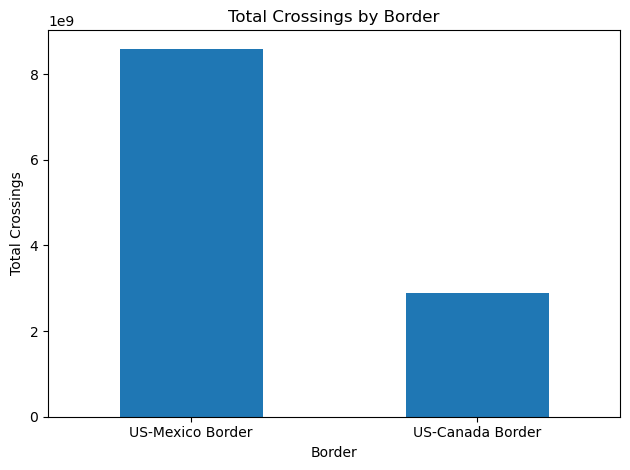

In [15]:
import matplotlib.pyplot as plt

pdf = border_analysis.toPandas()

pdf.plot(kind="bar", x="Border", y="Total_Crossings", legend=False)

plt.title("Total Crossings by Border")
plt.xlabel("Border")
plt.ylabel("Total Crossings")

plt.xticks(rotation=0)   # rotae x-axis labels 90 for better readability

plt.tight_layout()
plt.show()

### 5.2 Total Crossings by Measure

This analysis identifies which transportation measures (e.g., vehicles, pedestrians, trucks) contribute the most to total crossings.

In [16]:
measure_analysis = df.groupBy("Measure") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Total_Crossings", ascending=False)

measure_analysis.show()

+--------------------+---------------+
|             Measure|Total_Crossings|
+--------------------+---------------+
|Personal Vehicle ...|     6506215972|
|   Personal Vehicles|     3148059957|
|         Pedestrians|     1303898913|
|              Trucks|      340546108|
|      Bus Passengers|      160027594|
|               Buses|        9545006|
|    Train Passengers|        7529303|
|              Trains|        1120396|
+--------------------+---------------+



### 5.3 Total Crossings by Year

This analysis examines how total crossings change over time, revealing long-term trends and potential external impacts.

In [10]:
from pyspark.sql.functions import to_date, year

df = df.withColumn("Date_parsed", to_date("Date", "MMM yyyy"))
df = df.withColumn("Year", year("Date_parsed"))

df.select("Date", "Date_parsed", "Year").show(5, False)

+--------+-----------+----+
|Date    |Date_parsed|Year|
+--------+-----------+----+
|Jan 2026|2026-01-01 |2026|
|Jan 2026|2026-01-01 |2026|
|Dec 2025|2025-12-01 |2025|
|Nov 2025|2025-11-01 |2025|
|Jul 2025|2025-07-01 |2025|
+--------+-----------+----+
only showing top 5 rows


In [11]:
from pyspark.sql.functions import to_date, year, sum

# Extract year from Date column
df = df.withColumn("Date_parsed", to_date("Date", "MMM yyyy"))
df = df.withColumn("Year", year("Date_parsed"))

# Total crossings by year
year_analysis = df.groupBy("Year") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Year")

year_analysis.show()

+----+---------------+
|Year|Total_Crossings|
+----+---------------+
|1996|      424326538|
|1997|      487571047|
|1998|      498367381|
|1999|      526057768|
|2000|      527422164|
|2001|      479842216|
|2002|      462021027|
|2003|      443017400|
|2004|      444305796|
|2005|      436112146|
|2006|      426158914|
|2007|      403615100|
|2008|      386600603|
|2009|      348090864|
|2010|      331717926|
|2011|      319518381|
|2012|      331070167|
|2013|      342606811|
|2014|      349085046|
|2015|      350542766|
+----+---------------+
only showing top 20 rows


In [12]:
spark.sql("""
SELECT YEAR(to_date(Date, 'MMM yyyy')) AS Year,
       SUM(Value) AS Total_Crossings
FROM crossings
GROUP BY YEAR(to_date(Date, 'MMM yyyy'))
ORDER BY Year
""").show()

+----+---------------+
|Year|Total_Crossings|
+----+---------------+
|1996|      424326538|
|1997|      487571047|
|1998|      498367381|
|1999|      526057768|
|2000|      527422164|
|2001|      479842216|
|2002|      462021027|
|2003|      443017400|
|2004|      444305796|
|2005|      436112146|
|2006|      426158914|
|2007|      403615100|
|2008|      386600603|
|2009|      348090864|
|2010|      331717926|
|2011|      319518381|
|2012|      331070167|
|2013|      342606811|
|2014|      349085046|
|2015|      350542766|
+----+---------------+
only showing top 20 rows


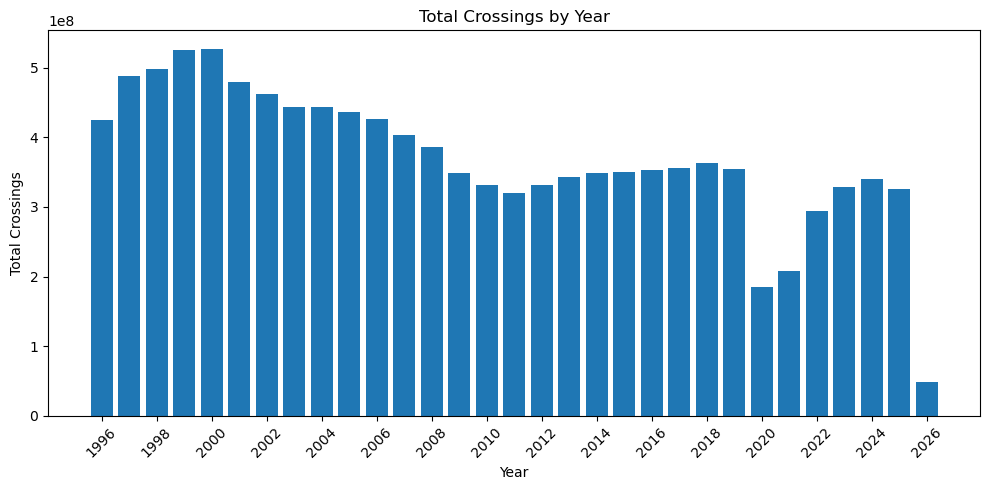

In [13]:
import matplotlib.pyplot as plt

pdf = year_analysis.toPandas()

plt.figure(figsize=(10,5))  

plt.bar(pdf["Year"], pdf["Total_Crossings"])

plt.title("Total Crossings by Year")
plt.xlabel("Year")
plt.ylabel("Total Crossings")

plt.xticks(pdf["Year"][::2], rotation=45) 

plt.tight_layout()
plt.show()

### 5.4 Top Ports by Total Crossings

This analysis identifies the busiest border ports based on total crossing volume.

In [14]:
port_analysis = df.groupBy("Port Name") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Total_Crossings", ascending=False)

port_analysis.show(10)

+--------------------+---------------+
|           Port Name|Total_Crossings|
+--------------------+---------------+
|          San Ysidro|     1449798032|
|             El Paso|     1308744295|
|              Laredo|      741498521|
|             Hidalgo|      660325848|
|            Calexico|      630228448|
|         Brownsville|      612299728|
|Buffalo Niagara F...|      592241423|
|           Otay Mesa|      562269475|
|             Detroit|      506840195|
|             Nogales|      481449582|
+--------------------+---------------+
only showing top 10 rows


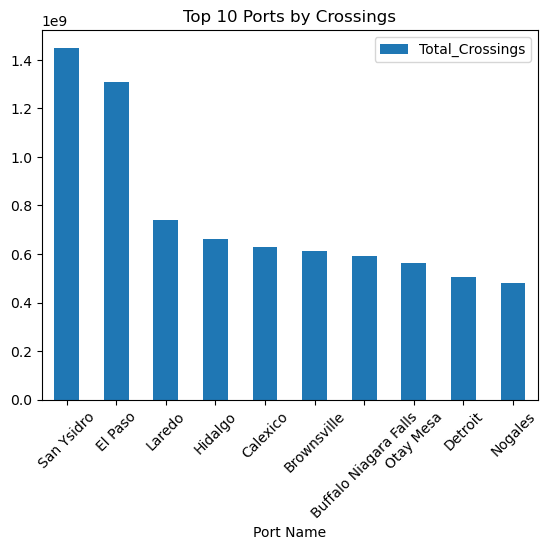

In [15]:
pdf = port_analysis.limit(10).toPandas()

pdf.plot(kind="bar", x="Port Name", y="Total_Crossings")
plt.title("Top 10 Ports by Crossings")
plt.xticks(rotation=45)
plt.show()

## 6. Equivalent Analysis with Spark SQL

This section demonstrates the use of Spark SQL to perform equivalent analyses, highlighting the flexibility of Spark’s unified processing engine.

### 6.1 Total Crossings by Border

### 6.2 Total Crossings by Measure

### 6.3 Total Crossings by Year

### 6.4 Top Ports by Total Crossings

## 7. MongoDB Aggregation Queries

In this section, we perform similar aggregations using MongoDB’s aggregation framework to compare with Spark-based processing.

### 7.1 Total Crossings by Border

### 7.2 Total Crossings by Measure

### 7.3 Total Crossings by Year

### 7.4 Top Ports by Total Crossings

## 8. Performance Comparison and Optimization

This section evaluates query performance across different approaches, including PySpark DataFrame API, Spark SQL, and MongoDB aggregation.

We also demonstrate optimization techniques such as:
- Spark caching
- Query execution plan analysis
- MongoDB indexing

### 8.1 Performance Comparison

### 8.2 Spark Optimization

### 8.3 MongoDB Optimization

## 9. Advanced Meaningful Analyses

Each member is responsible for one analysis question.

For each subsection:
- Clearly answer the question
- Include at least one visualization
- Provide a short interpretation of the results
- Write the final dataset back to MongoDB

You are encouraged to explore beyond the minimum requirements if you find interesting patterns.

### 9.1 Long-term Changes in Border Crossing Structure

Question:
How have transportation patterns evolved over time at the U.S.-Canada and U.S.-Mexico borders?

### 9.2 Peak Month and Peak Volume for Top Ports

Question:
For the top ports at each border, which month has the highest crossing volume?

(Hint: identify both the peak month and the corresponding volume, and compare patterns across ports.)

### 9.3 Impact of External Events (COVID-19)

Question:
How did COVID-19 affect border crossing volumes over time?

(Hint: compare trends before, during, and after the pandemic, and look for disruptions and recovery patterns.)

In [16]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "Period",
    when(col("Year") < 2020, "Before COVID")
    .when((col("Year") >= 2020) & (col("Year") <= 2021), "During COVID")
    .otherwise("After COVID")
)

In [17]:
from pyspark.sql.functions import sum

covid_analysis = df.groupBy("Period") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Period")

covid_analysis.show()

+------------+---------------+
|      Period|Total_Crossings|
+------------+---------------+
| After COVID|     1338860168|
|Before COVID|     9744627200|
|During COVID|      393455881|
+------------+---------------+



In [22]:
spark.sql("""
SELECT
  CASE
    WHEN YEAR(to_date(Date, 'MMM yyyy')) < 2020 THEN 'Before COVID'
    WHEN YEAR(to_date(Date, 'MMM yyyy')) BETWEEN 2020 AND 2021 THEN 'During COVID'
    ELSE 'After COVID'
  END AS Period,
  SUM(Value) AS Total_Crossings
FROM crossings
GROUP BY
  CASE
    WHEN YEAR(to_date(Date, 'MMM yyyy')) < 2020 THEN 'Before COVID'
    WHEN YEAR(to_date(Date, 'MMM yyyy')) BETWEEN 2020 AND 2021 THEN 'During COVID'
    ELSE 'After COVID'
  END
ORDER BY Period
""").show()

+------------+---------------+
|      Period|Total_Crossings|
+------------+---------------+
| After COVID|     1338860168|
|Before COVID|     9744627200|
|During COVID|      393455881|
+------------+---------------+



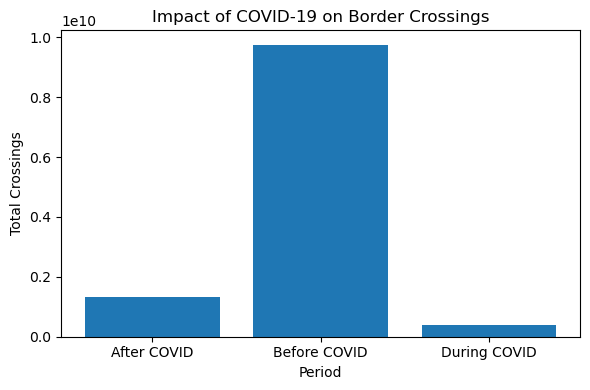

In [21]:
import matplotlib.pyplot as plt

pdf = covid_analysis.toPandas()

plt.figure(figsize=(6,4))
plt.bar(pdf["Period"], pdf["Total_Crossings"])

plt.title("Impact of COVID-19 on Border Crossings")
plt.xlabel("Period")
plt.ylabel("Total Crossings")

plt.tight_layout()
plt.show()

### 9.4 Port Growth & Decline Analysis

Question:
Which ports have experienced the most significant growth or decline over time?

(Hint: compare two time points and consider both absolute and relative changes.)